In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Ссылка на документацию

https://seaborn.pydata.org/generated/seaborn.heatmap.html

In [8]:
# Загрузка датасета
df = sns.load_dataset('penguins')

# Смотрим на структуру данных
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


# Настройка стиля

## Тема 

Эти настройки глобальные. Если вы прописали sns.set_theme() в начале ноутбука, все последующие графики будут следовать этому стилю. Вам не нужно дублировать код оформления.

In [40]:
sns.set_theme(style="darkgrid")

У Seaborn есть 5 встроенных тем оформления:

- darkgrid (по умолчанию) — серый фон с сеткой, отлично подходит для анализа распределений.
- whitegrid — белый фон с сеткой, хорош для «тяжелых» графиков, где серый фон может мешать.
- dark — просто серый фон.
- white — чистый белый фон.
- ticks — белый фон с засечками на осях (максимально похоже на классический стиль, но аккуратнее).

# Цветовые палитры Matplotlib

В Matplotlib есть несколько типов встроенных палитр (colormaps):

1. Последовательные (Sequential)  
'viridis', 'plasma', 'inferno', 'magma', 'cividis', 'Greys', 'Purples', 'Blues', 'Greens', 'Oranges', 'Reds', 'YlOrBr', 'YlOrRd', 'OrRd', 'PuRd', 'RdPu', 'BuPu', 'GnBu', 'PuBu', 'YlGnBu', 'PuBuGn', 'BuGn', 'YlGn'

2. Дивергентные (Diverging)  
'PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu', 'RdYlGn', 'Spectral', 'coolwarm', 'bwr', 'seismic'

3. Циклические (Cyclic)  
'twilight', 'twilight_shifted', 'hsv'

4. Качественные (Qualitative)  
'Pastel1', 'Pastel2', 'Paired', 'Accent', 'Dark2', 'Set1', 'Set2', 'Set3', 'tab10', 'tab20', 'tab20b', 'tab20c'

5. Прочие  
'afmhot', 'autumn', 'bone', 'cool', 'copper', 'flag', 'gist_earth', 'gist_gray', 'gist_heat', 'gist_ncar', 'gist_rainbow', 'gist_stern', 'gnuplot', 'gnuplot2', 'gray', 'hot', 'hsv', 'jet', 'nipy_spectral', 'ocean', 'pink', 'prism', 'rainbow', 'spring', 'summer', 'terrain', 'winter'

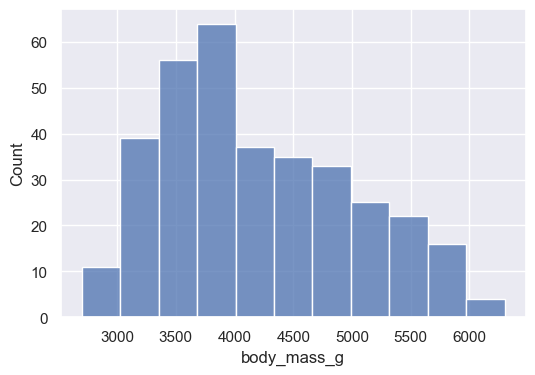

In [43]:
# Простой график для теста
plt.figure(figsize=(6, 4))
sns.histplot(data=df, x="body_mass_g")
plt.show()

## Масштабирование под задачу (Context)

Частая проблема: вы настроили график в Jupyter Notebook, он выглядит отлично. Вставляете его в презентацию PowerPoint — и аудитория не видит подписей осей, потому что они слишком мелкие.

Вместо того чтобы вручную менять fontsize для каждого элемента, используйте контекст. Seaborn умеет масштабировать все элементы графика (шрифты, линии, точки) под ситуацию.

Доступные контексты (по возрастанию масштаба):

- paper (для научных статей)
- notebook (дефолтный)
- talk (для презентаций)
- poster (для печати плакатов)

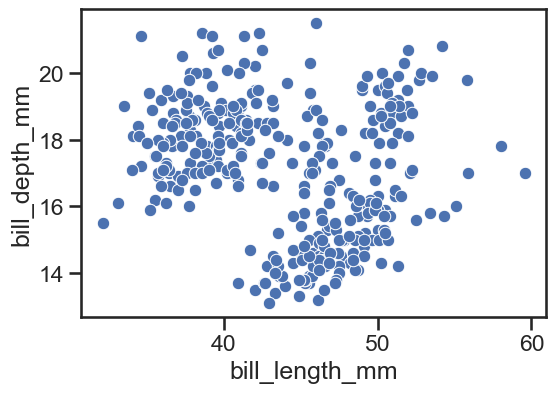

In [53]:
# Делаем элементы крупнее и жирнее для слайдов
sns.set_theme(style="ticks", context="talk")

plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm")
plt.show()

# Гистограмма распределения

Прежде чем искать связи между данными, нужно понять, как они выглядят сами по себе. Нормальное ли распределение? Есть ли выбросы? Где сосредоточено большинство значений?

Для этого используются гистограммы. В Seaborn основной инструмент здесь — функция sns.histplot().

## Базовая гистограмма + KDE
Давайте посмотрим на распределение массы тела пингвинов (body_mass_g). Чтобы график был информативнее, добавим параметр kde=True (Kernel Density Estimate) — это сглаженная линия, показывающая плотность распределения. Она помогает увидеть форму графика, игнорируя шум от разбиения на "корзины" (bins).

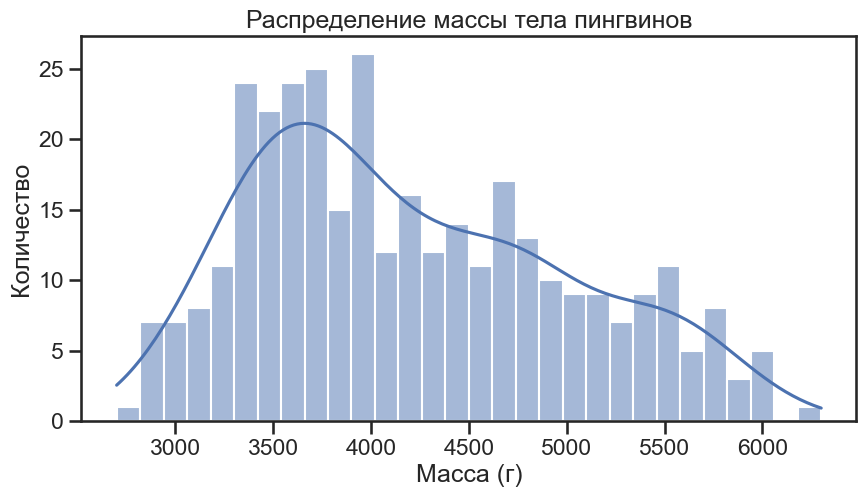

In [82]:
fig, axes = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="body_mass_g", kde=True, bins=30)
axes.set_title("Распределение массы тела пингвинов", fontdict={'fontsize': 18})
axes.set_xlabel("Масса (г)", fontdict={'fontsize': 18})
axes.set_ylabel("Количество", fontdict={'fontsize': 18});

## Разделение по категориям (Параметр hue)
Представьте, что вам нужно построить три такие гистограммы на одном графике — отдельно для каждого вида пингвинов. В чистом Matplotlib вам пришлось бы фильтровать DataFrame три раза и вызывать plt.hist для каждой выборки.

В Seaborn за это отвечает один параметр — hue (оттенок). Вы просто указываете колонку, по которой нужно разбить данные, и библиотека сама раскрасит график и добавит легенду.

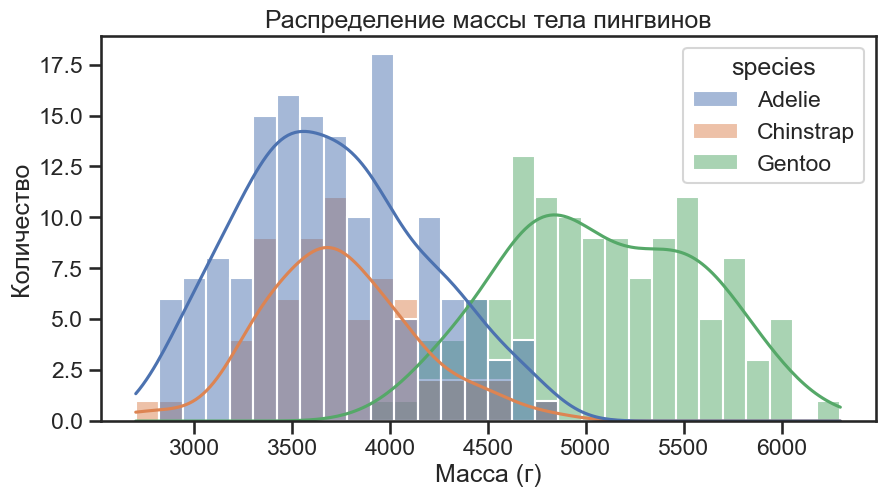

In [84]:
fig, axes = plt.subplots(figsize=(10, 5))
sns.histplot(data=df, x="body_mass_g", kde=True, bins=30, hue='species')
axes.set_title("Распределение массы тела пингвинов", fontdict={'fontsize': 18})
axes.set_xlabel("Масса (г)", fontdict={'fontsize': 18})
axes.set_ylabel("Количество", fontdict={'fontsize': 18});

# Scatterplot (Отношения переменных)

Когда нужно найти зависимость между двумя числовыми переменными (корреляцию), мы используем — Scatterplot (точечная диаграмма).

В Matplotlib создание такого графика — дело нехитрое (plt.scatter), но сложности начинаются, когда вы хотите добавить в этот график контекст. Например, покрасить точки в зависимости от категории или изменить их размер в зависимости от веса. В Seaborn это делается передачей названий колонок в соответствующие аргументы.

Давайте посмотрим зависимость длины клюва (bill_length_mm) от его глубины (bill_depth_mm). Но чтобы выжать из графика максимум, мы добавим еще два измерения:

- Цвет (hue): Будет отвечать за вид пингвина.
- Размер (size): Будет показывать массу тела (body_mass_g).

Таким образом, мы получим 4D-график на плоском экране.

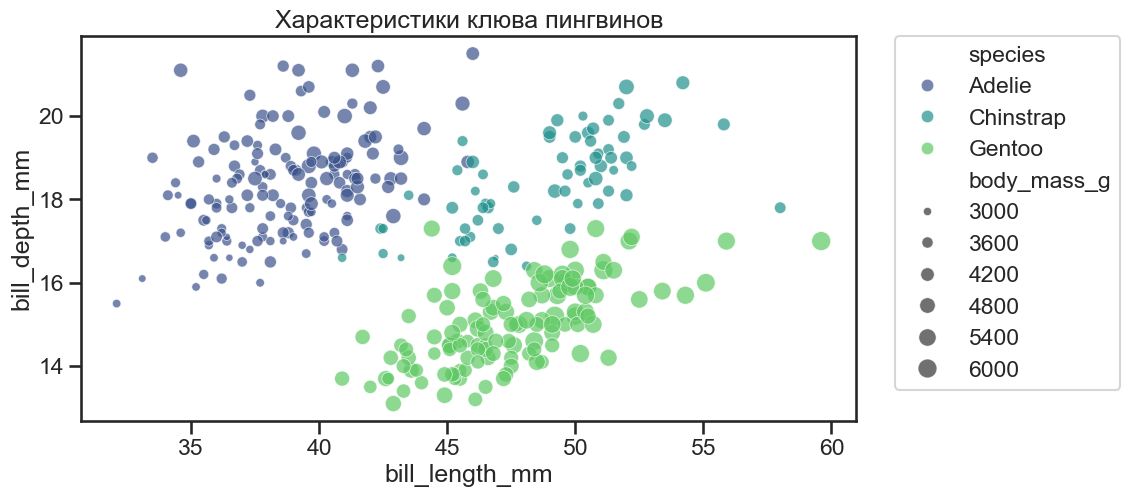

In [406]:
plt.figure(figsize=(10, 5))
sns.scatterplot(
    data=df,
    x="bill_length_mm", 
    y="bill_depth_mm",
    hue="species",       # 3-е измерение: цвет по виду
    size="body_mass_g",  # 4-е измерение: размер точки по весу пингвина
    sizes=(20, 200),     # Задаем диапазон размеров точек (мин, макс)
    alpha=0.7,           # Немного прозрачности для наложений
    palette="viridis"    # Красивая цветовая гамма
)

plt.title("Характеристики клюва пингвинов")
# Легенду можно подвинуть, если она мешает (bbox_to_anchor)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0)
plt.show()

Если бы мы построили этот график без hue="species", мы бы увидели просто облако точек и могли бы ошибочно решить, что корреляции нет или она слабая.

Однако разбиение по цветам сразу выявляет скрытую структуру (так называемый парадокс Симпсона):

- У каждого вида пингвинов есть четкая зависимость: чем длиннее клюв, тем он глубже (или наоборот, в зависимости от вида).
- Виды идеально кластеризуются: Gentoo (обычно самые крупные точки) живут в своей области графика.

# Barplot (столбчатая диаграмма)

Часто перед аналитиком стоит задача сравнить показатели между группами. Кто тяжелее: самцы или самки? На каком острове пингвины имеют самый длинный клюв? Для этого мы используем графики, где одна ось — это категория (текст), а вторая — число.

В Matplotlib, чтобы построить график среднего значения по группам, вам сначала нужно сделать groupby(), посчитать .mean(), и только потом рисовать.

sns.barplot() делает это за вас. По умолчанию он считает среднее значение для каждой категории.

Обратите внимание на черные полоски сверху каждого столбца. Это не «антенны», это доверительный интервал (по умолчанию 95%). Seaborn автоматически рассчитывает его методом бутстрапа. Если полоска короткая — значит, данных много и разброс небольшой (мы уверены в среднем значении). Если длинная — данных мало или они очень шумные.

- Если нужно не среднее, а, например, медиана или сумма, передайте соответствующую функцию в параметр estimator (например, estimator=sum).
- Если нужно отключить доверительные интервалы, передайте в параметр errorbar=None

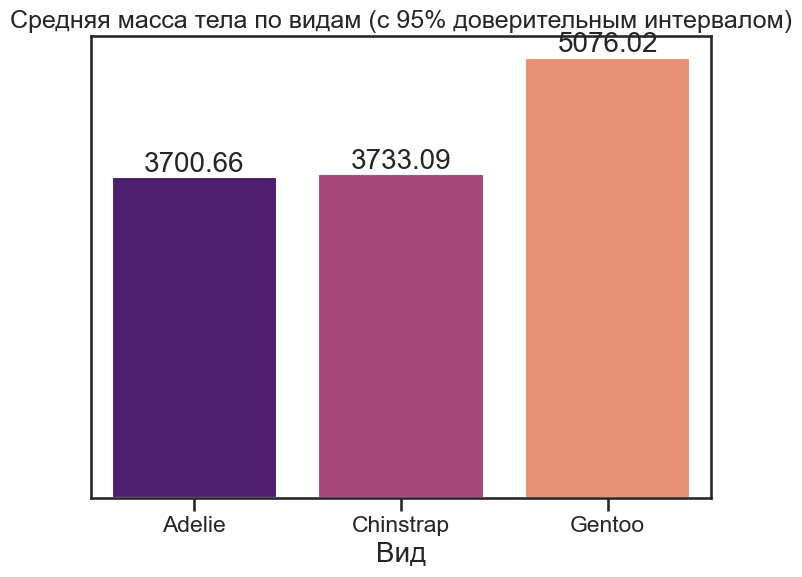

In [360]:
plt.figure(figsize=(8, 6))

ax = sns.barplot(data=df, x="species", y="body_mass_g", hue='species', palette='magma', estimator='mean', errorbar=None)
plt.title("Средняя масса тела по видам (с 95% доверительным интервалом)")
# перебирает все наборы столбцов (контейнеры) на графике
# container - отдельный столбец, ax.containers - все столбцы.
for container in ax.containers:
    ax.bar_label(container, fontsize=20, label_type = 'edge')

ax.set_xlabel("Вид", fontdict={'fontsize': 20})
ax.set_ylabel("Масса (г)", fontdict={'fontsize': 20});

ax.yaxis.set_visible(False) # скрывает ось y

## Цветовые палитры

Эти палитры используются по умолчанию для дискретных категорий:

- "deep" (палитра по умолчанию)
- "muted" (приглушенные цвета)
- "pastel" (пастельные тона)
- "bright" (яркие цвета)
- "dark" (темные цвета)
- "colorblind" (адаптирована для дальтоников)

# Boxplot (Ящик с усами)

Это стандарт де-факто для поиска аномалий.

- Коробка: показывает интерквартильный размах (от 25% до 75% данных). Полоса внутри — медиана.
- Усы: основная масса данных.
- Точки за усами: выбросы (outliers). Именно на них стоит обратить внимание при чистке данных.

Давайте усложним задачу: посмотрим распределение массы не только по видам, но и по полу.

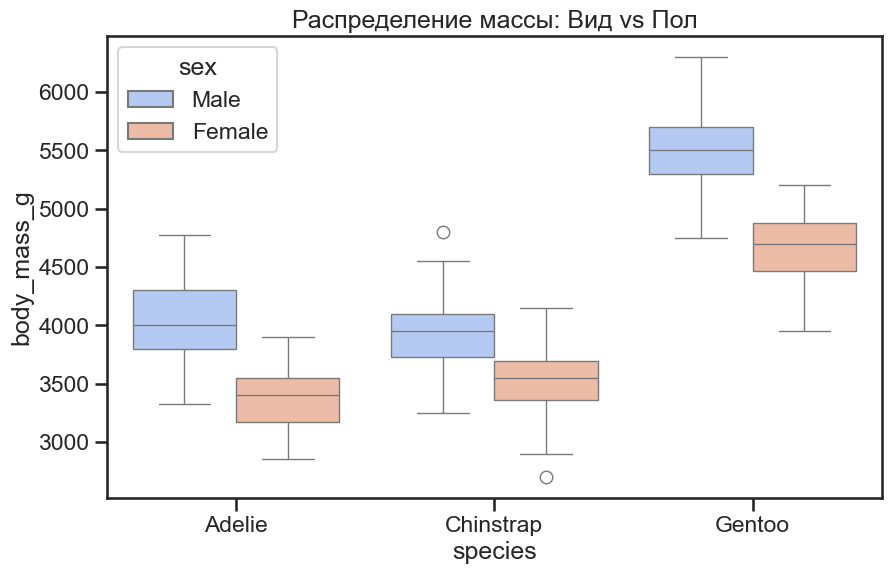

In [329]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="species", y="body_mass_g", hue="sex", palette="coolwarm")

plt.title("Распределение массы: Вид vs Пол")
plt.show()

# Линейные графики и временные ряды

Если ваши данные имеют временную привязку (продажи по дням, курс валют, трафик на сайте), то ваш выбор — sns.lineplot().

Для этого примера нам придется попрощаться с пингвинами (они не меняются во времени) и загрузить датасет flights, который показывает количество авиапассажиров по месяцам с 1949 по 1960 год.

In [182]:
flights = sns.load_dataset("flights")
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


В Matplotlib, если у вас есть несколько точек данных для одного значения X (например, 12 месяцев для 1949 года), и вы построите линейный график, вы получите кашу из вертикальных линий.

Seaborn умнее. Если вы передадите ему «сырые» данные, он автоматически:

- Посчитает среднее значение для каждой точки X (года).
- Нарисует полупрозрачную тень вокруг линии — это доверительный интервал (confidence interval).

Эта тень показывает разброс данных. Если она узкая — значения в этом году были стабильны. Если широкая — была сильная волатильность (сезонность).

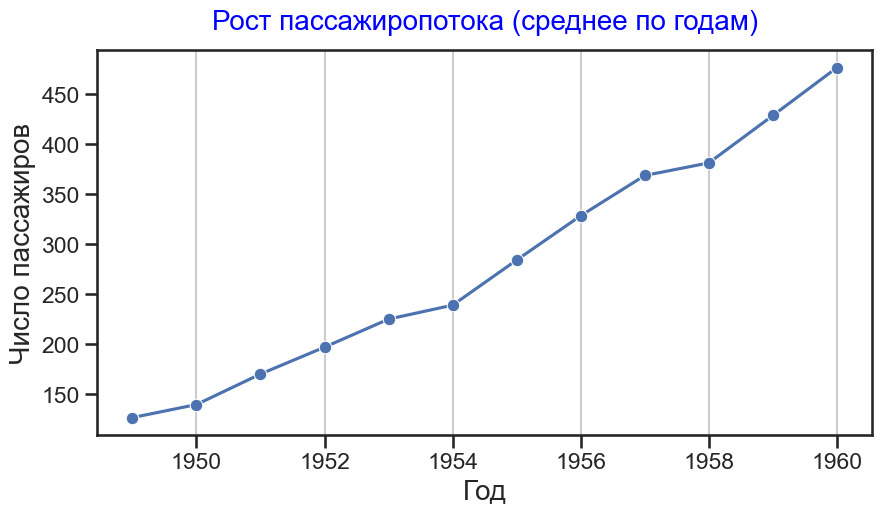

In [386]:
plt.figure(figsize=(10,5))

ax = sns.lineplot(data=flights, x='year', y='passengers', marker='o', errorbar=None) # color='red', 'green', 'blue', 'orange' и тд.
ax.set_xlabel('Год', fontdict={'fontsize':20})
ax.set_ylabel('Число пассажиров', fontdict={'fontsize':20})

ax.set_title('Рост пассажиропотока (среднее по годам)', fontdict={'fontsize':20, 'color':'blue'}, pad=15)
ax.grid(which='major', axis='x')

Вы сразу видите глобальный тренд: количество пассажиров растет. Тень говорит нам о том, что с годами увеличивается не только среднее количество, но и разброс между «тихими» и «популярными» месяцами (тень расширяется к концу графика).

Если мы хотим видеть не среднюю температуру по больнице, а каждый месяц отдельно, используем уже знакомый параметр hue.

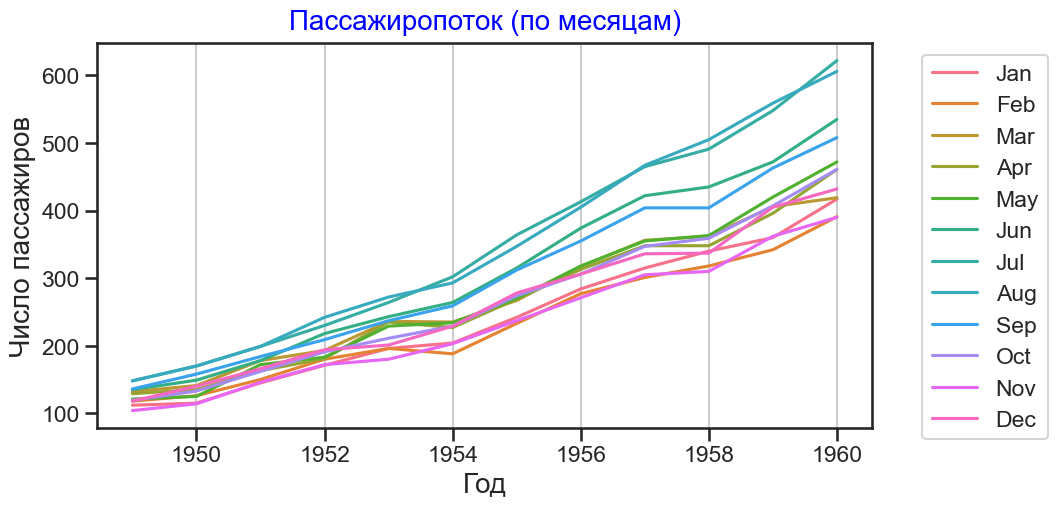

In [230]:
plt.figure(figsize=(10,5))

ax = sns.lineplot(data=flights, x='year', y='passengers', hue = 'month')
ax.set_xlabel('Год', fontdict={'fontsize':20})
ax.set_ylabel('Число пассажиров', fontdict={'fontsize':20})

ax.set_title('Пассажиропоток (по месяцам)', fontdict={'fontsize':20, 'color':'blue'}, pad=10)
ax.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
ax.grid(which='major', axis='x')

Теперь мы видим четкую сезонность: летом (светлые и зеленые линии) летают гораздо больше, чем зимой (фиолетовые линии), и этот разрыв увеличивается с каждым годом.

# Heatmap (Тепловая карта)

Если Scatterplot показывает отношение двух переменных, то Heatmap позволяет взглянуть на все отношения сразу. Это самый эффектный способ визуализировать таблицы, где значения кодируются цветом.

## Кейс 1: Матрица корреляций 

Самая частая задача в Data Science: «Что с чем связано?». Зависит ли масса тела пингвина от длины его клюва?

Чтобы это узнать, сначала строим матрицу корреляций с помощью Pandas (.corr()), а затем скармливаем её в sns.heatmap().

In [245]:
# Рассчитываем корреляцию (только для числовых колонок)
# numeric_only=True обязателен в новых версиях Pandas, чтобы игнорировать текстовые поля
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


## Цветовые палитры

Дивергентные палитры (для данных с нулевой точкой)
Используются, когда данные имеют значимую середину (например, положительные и отрицательные значения):
- "coolwarm" (от холодного к теплому)
- "RdBu" (красный-синий)
- "BrBG" (коричневый-зеленый)
- "PiYG" (розовый-зеленый)
- "PRGn" (пурпурный-зеленый)
- "PuOr" (пурпурный-оранжевый)
- "RdGy" (красный-серый)
- "RdYlBu" (красный-желтый-синий)
- "RdYlGn" (красный-желтый-зеленый)
- "Spectral"

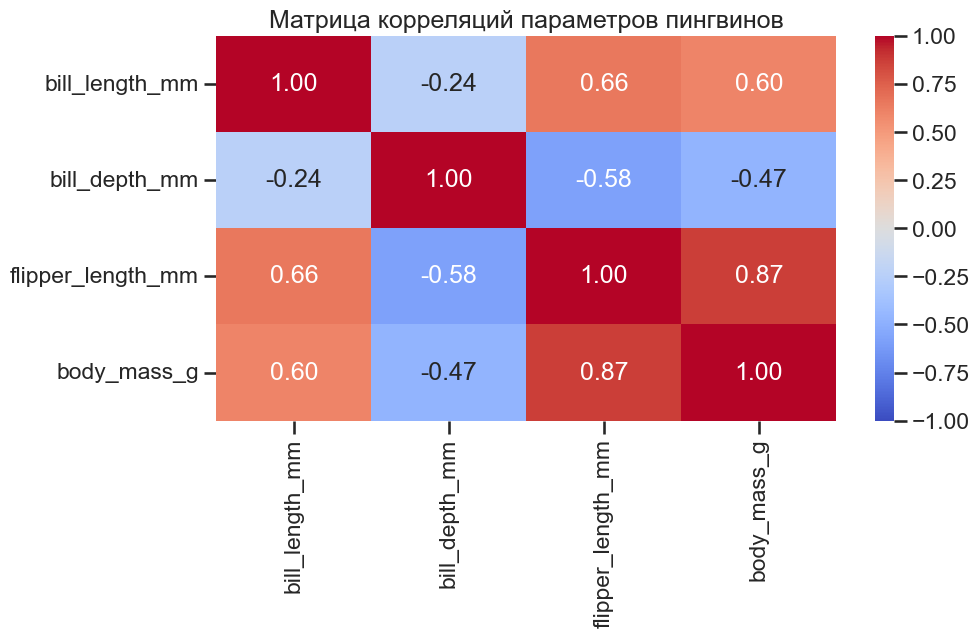

In [388]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_matrix, 
    annot=True,      # Пишем значения внутри ячеек
    cmap='coolwarm', # Цветовая гамма (синий-белый-красный)
    fmt=".2f",       # Формат чисел (2 знака после запятой)
    vmin=-1, vmax=1  # Фиксируем границы цветов (от -1 до 1)
)

plt.title("Матрица корреляций параметров пингвинов")
plt.show()

На что смотреть:

- Красный (близко к 1): Сильная прямая связь. Например, flipper_length_mm и body_mass_g (0.87) — чем длиннее ласты, тем тяжелее пингвин. Логично.

- Синий (близко к -1): Обратная связь.

- Белый (около 0): Связи нет.

Лайфхак: используйте палитру coolwarm или RdBu для корреляций, чтобы ноль всегда был нейтрального (белого) цвета.

## Кейс 2: Временная сетка

Вернемся к датасету flights. Линейный график показал нам тренд, но Heatmap может показать структуру сезона еще нагляднее.

Для этого нам нужно превратить длинную таблицу в широкую (сводную), где строки — это месяцы, а столбцы — годы.

In [264]:
flights.head()

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


In [282]:
flights_matrix = flights.pivot(index='year', columns='month', values='passengers')
flights_matrix

month,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
year,,,,,,,,,,,,
1949,112,118,132,129,121,135,148,148,136,119,104,118
1950,115,126,141,135,125,149,170,170,158,133,114,140
1951,145,150,178,163,172,178,199,199,184,162,146,166
1952,171,180,193,181,183,218,230,242,209,191,172,194
1953,196,196,236,235,229,243,264,272,237,211,180,201
1954,204,188,235,227,234,264,302,293,259,229,203,229
1955,242,233,267,269,270,315,364,347,312,274,237,278
1956,284,277,317,313,318,374,413,405,355,306,271,306
1957,315,301,356,348,355,422,465,467,404,347,305,336


## Цветовые палитры

Последовательные палитры (для упорядоченных данных)
Подходят для непрерывных данных с градацией от светлого к темному:

- Оттенки одного цвета: "Blues", "Greens", "Reds", "Purples", "Oranges", "Greys"

- Смешанные: "BuGn", "BuPu", "GnBu", "OrRd", "PuBu", "PuBuGn", "PuRd", "RdPu", "YlGn", "YlGnBu", "YlOrBr", "YlOrRd"

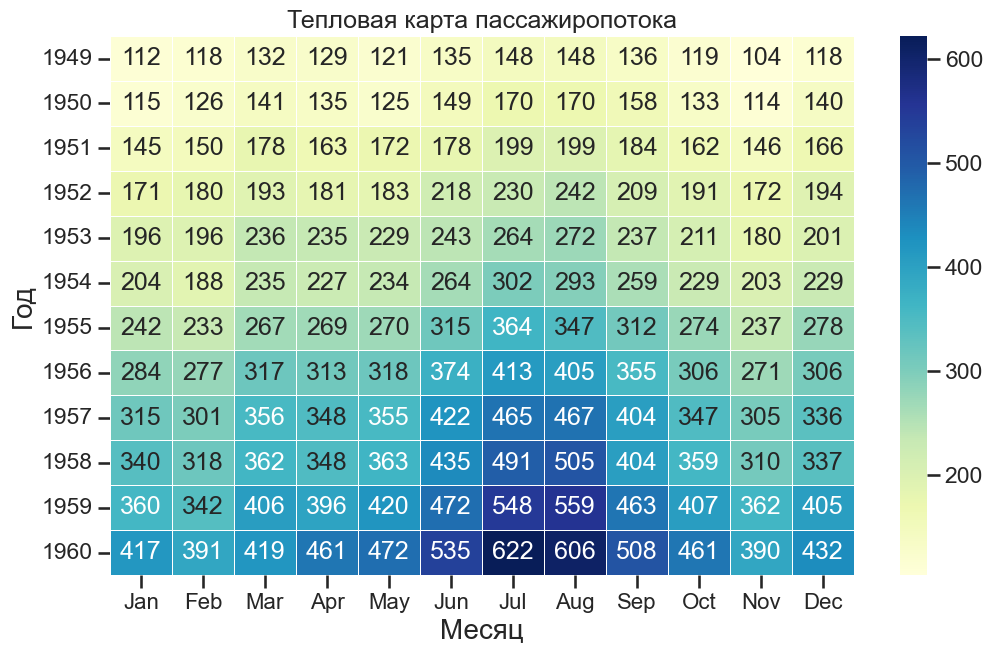

In [458]:
plt.figure(figsize=(12, 7))
sns.heatmap(
    flights_matrix, 
    cmap="YlGnBu",   # Желто-зелено-синяя палитра (хороша для количеств)
    linewidths=0.5,  # Делаем сетку между ячейками
    annot=True, 
    fmt="d"          # Формат "d" (integer) для целых чисел
)

plt.title("Тепловая карта пассажиропотока")

plt.xlabel('Месяц', fontsize=20)
plt.ylabel('Год', fontsize=20)
plt.xticks(fontsize=16);

Теперь мы видим данные как «плитку».

- По горизонтали: Видно, что июль и август (самые темные ячейки) — самые загруженные месяцы в любом году.
- По вертикали: Видно, как с годами цвет становится все темнее (общий рост потока).

Это идеальный график для поиска сезонных паттернов и аномалий в продажах, трафике или активности пользователей.

# Быстрый обзор всего датасета (Pairplot)

Представьте, что вы только что получили новый датасет. Вы еще не знаете, какие параметры важны, а какие — мусор. Вам нужно провести EDA (Exploratory Data Analysis) и быстро взглянуть на все возможные связи.

Строить 10 разных scatterplot вручную — долго.
sns.pairplot() делает это одной командой.

Эта функция берет все числовые переменные вашего датасета и строит сетку графиков «каждый с каждым».

In [291]:
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


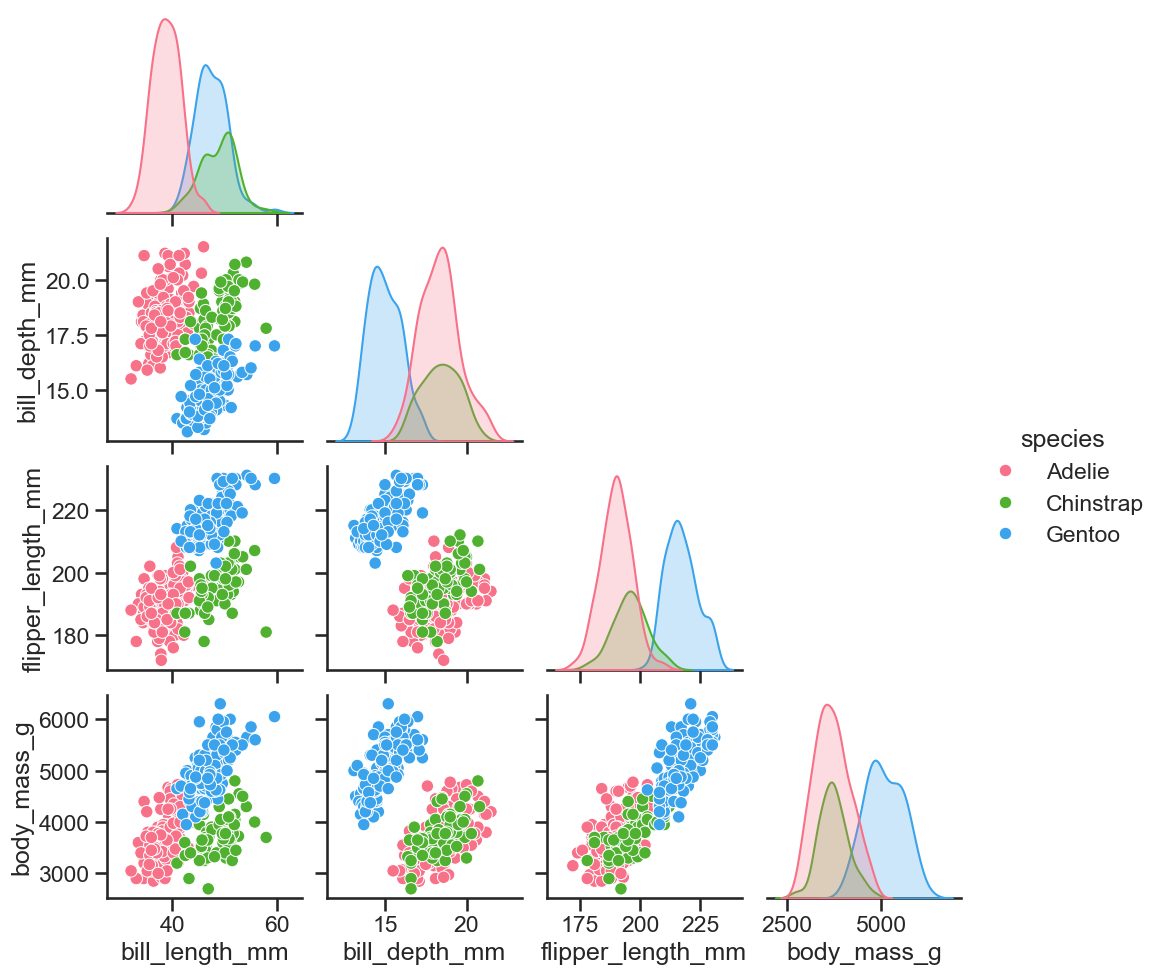

In [293]:
# Строим сетку графиков
# corner=True убирает дублирующиеся графики сверху (зеркальные), делая картинку чище
sns.pairplot(df, hue="species", palette="husl", corner=True)

plt.show()

Как читать этот график?
Вы получите треугольную сетку (благодаря corner=True), где:

- По диагонали: Расположены графики распределения (KDE или гистограммы) для каждой конкретной переменной. Здесь мы видим, как разделяются виды пингвинов по каждому отдельному параметру.
- Остальные ячейки: Это scatterplot для пары переменных (пересечение строки и столбца).

Это мощнейший инструмент для поиска инсайтов:

- Вы сразу видите, какие пары переменных линейно зависимы (выстраиваются в линию).
- Вы видите, какие признаки лучше всего разделяют классы (например, если на диагонали горбы разных цветов далеко друг от друга — это отличный признак для модели машинного обучения).

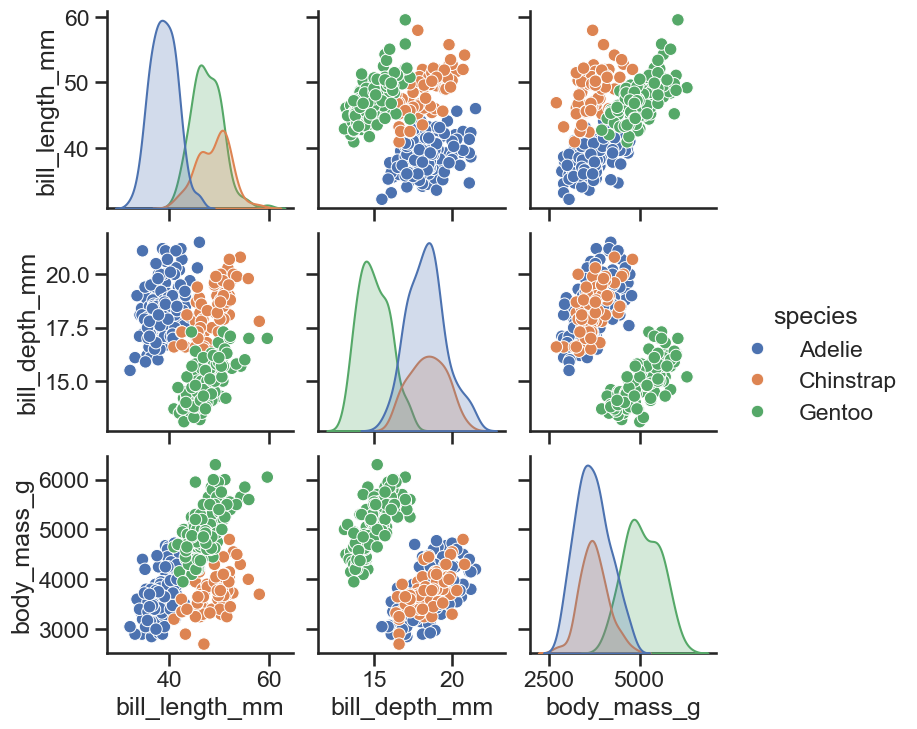

In [297]:
# Если датасет большой, выбирайте только интересные колонки явно:

# Выбираем только конкретные колонки для анализа
cols_to_plot = ["bill_length_mm", "bill_depth_mm", "body_mass_g"]

sns.pairplot(df, vars=cols_to_plot, hue="species")
plt.show()

Используйте pairplot как инструмент первой разведки, чтобы понять, куда копать дальше.

# Кастомизация

Вы построили график, нашли инсайт, и теперь картинку нужно вставить в отчет или презентацию. Но вот беда: подписи осей на английском (названия колонок), заголовок отсутствует, а размер картинки слишком мал.

Вот универсальный рецепт «причесывания» графика перед публикацией:

- Размер: Задаем plt.figure() до команды построения графика.

- Подписи: Используем plt.title, plt.xlabel, plt.ylabel после построения.

- Сохранение: Используем plt.savefig вместо plt.show.

## Полный пайплайн

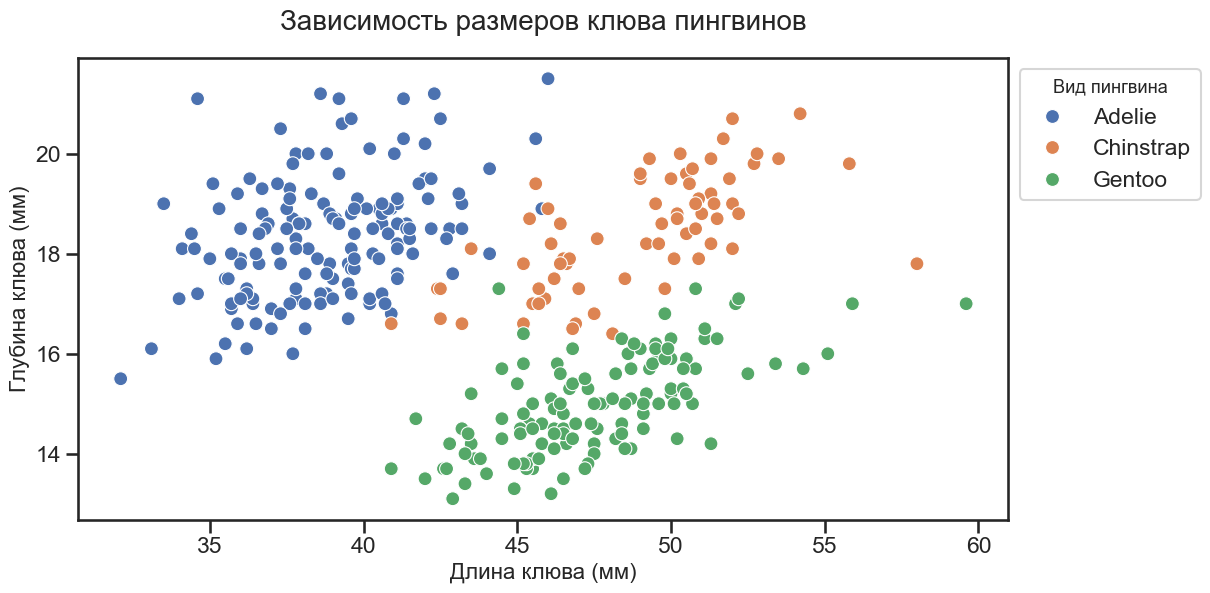

In [318]:
# 1. Задаем размер полотна в дюймах (Ширина, Высота)
plt.figure(figsize=(12, 6))

# 2. Рисуем график
# Добавим параметр s=100, чтобы точки были крупнее
sns.scatterplot(data=df, x="bill_length_mm", y="bill_depth_mm", hue="species", s=100)

# 3. Настраиваем подписи (можно использовать русский язык)
plt.title("Зависимость размеров клюва пингвинов", fontsize=20, pad=20)
plt.xlabel("Длина клюва (мм)", fontsize=16)
plt.ylabel("Глубина клюва (мм)", fontsize=16)

# 4. Настраиваем легенду
# loc='best' — matplotlib сам найдет свободное место
plt.legend(title="Вид пингвина", title_fontsize='13', loc='upper left', bbox_to_anchor=(1.0, 1))

# 5. Сохраняем результат
# dpi=300 — высокое разрешение для печати
# bbox_inches='tight' — убирает лишние белые поля и гарантирует, что подписи не обрежутся
plt.savefig(r'C:\Users\ryagu\Downloads\penguins_final.png', dpi=300, bbox_inches='tight')

## Чек-лист важных параметров

- figsize=(12, 6): Если график кажется сплюснутым, играйте с этими числами. Для презентаций часто подходит соотношение 16:9.

- plt.xticks(rotation=45): Если подписи на оси X длинные и наезжают друг на друга (часто бывает с датами), эта команда повернет их на 45 градусов.

- bbox_inches='tight': Это "золотая" настройка при сохранении. Без неё Matplotlib часто обрезает длинные подписи осей или легенду, которая вылезла за край графика.

- dpi: Для экрана хватит 100-150, для печати или качественной презентации ставьте 300.

Теперь ваш график выглядит профессионально и готов к публикации.